# 量子最適化ベストプラクティス
# 2. Parameter Optimisation

Daito Sato, IBM Quantum (Apr 23, 2026)



このNotebookでは、パラメータの最適化を古典的に求める手法を扱います。

**注意点**

`qaoa-training-pipeline`はデフォルトでは以下の形式のコスト関数を想定しています

\begin{align}
H_C=\sum_{(i,j)\in E}w_{ij}\,Z_iZ_j
\end{align}

このコスト関数を最大化するように機能するのが`qaoa-training-pipeline`の特徴です。なので、実装しようとしているコスト関数に対して、
1. 式(1)の形式と比べどこが違うのか（例. 符号や係数）
2. コスト関数を最大化/最初化したいのか

を確認する必要があり、もし差がある場合は適切に符号や係数の処理が必要になってきます。

## 深さ$p=1$の場合のパラメータ最適化

このnotebookでは深さ$p=1$のケースを扱います。`qaoa-training-pipeline`では深さ1に特化した`Evaluator` (`EfficientDepthOneEvaluator`)と`Trainer` (`DepthOneScanTrainer`)があります

In [1]:
#必要なパッケージのインストール
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from qiskit.circuit.library import QAOAAnsatz

from qiskit_ibm_runtime import SamplerV2 as Sampler, EstimatorV2 as Estimator, Session

from qiskit_aer import AerSimulator

from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.evaluation import EfficientDepthOneEvaluator
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator
import time

from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import generate_preset_pass_manager

from scipy.optimize import minimize


### 例1. Max-Cut問題

ここでは最大化問題としてMax-Cut問題を扱います。例としてランダムに生成さらた25ノードのグラフ問題を対象にします

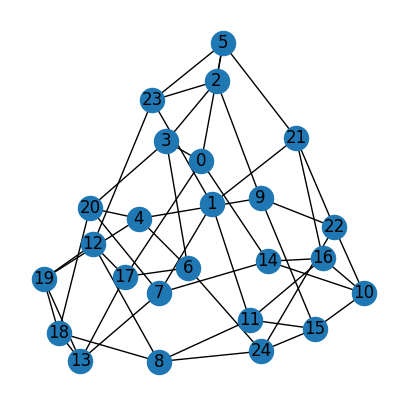

In [2]:
graph = nx.random_regular_graph(n=25, d=4, seed=0)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
nx.draw(graph, with_labels=True, ax=ax)

Max-Cut問題のコストハミルトニアンが以下のように定義されています。

\begin{align}
H_C^{\text{max-cut}}=-\sum_{(i,j)\in E}\frac{w_{ij}}{2}\,Z_iZ_j 
\end{align}

これを`qaoa-training-pipeline`で想定されるコストハミルトニアンと比較します。すると係数が$-\frac{1}{2}$だけ違うことに気づきます。このグラフからコストハミルトニアンを作る時はこの係数の違いを考慮する必要があります。

`qaoa-training-pipeline`では`graph_to_operator`という関数が、グラフをコストハミルトニアンに変換する機能を持っています。しかしながら、この関数はデフォルトでは係数を$+1$にしてしまいます。

In [3]:
cost_hamiltonian1 = graph_to_operator(graph)
print(cost_hamiltonian1)

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIZIIIIZ', 'IIIIIIIIIIZIIIIIIIIIIIIIZ', 'IIIIIIIZIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIZIIZ', 'IIIZIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIZIIIIIIIIIZI', 'IZIIIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIZIIIIIZI', 'IIIIIIIIIIIIIIIIIIIZIIZII', 'IZIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIZZII', 'IIIIIIIIIIIIIIIZIIIIIIZII', 'IIIIIIIIIIIIIIIIIIZIIZIII', 'IIIIZIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIZIIIIZIIII', 'IIIIIIIIIIIIIIIIIIZIZIIII', 'IIIIZIIIIIIIIIIIIIIIZIIII', 'IIIIIZIIIIIIIIIIIIIIZIIII', 'IIIZIIIIIIIIIIIIIIIZIIIII', 'IZIIIIIIIIIIIIIIIIIZIIIII', 'ZIIIIIIIIIIIIIIIIIZIIIIII', 'IIIIIIIZIIIIIIIIIIZIIIIII', 'IIIIZIIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIZIIIIIZIIIIIII', 'IIIIIIIIIIZIIIIIIZIIIIIII', 'IIIIIIIIIIIIZIIIZIIIIIIII', 'IIIIIIZIIIIIIIIIZIIIIIIII', 'ZIIIIIIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIIIIZIIZIIIIIIII', 'IIZIIIIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIZIIIIIZIIIIIIIII', 'IIIIIIIIIZIIIIZIIIIIIIIII', 'IIIIIIIIIIZIIIZIIIIIIIIII', 'IIIIIIIIZIIIIIZIIIIIIIIII',

今回のように、「デフォルトのコストハミルトニアン」と「皆さんが扱いたいコストハミルトニアン」に差がある場合、`graph_to_operator`の引数`pre_factor`を指定してあげることで帳尻合わせができます。今回の場合は$-\frac{1}{2}$だけ違うので、`pre_factor` $ = - 0.5$とします。

In [15]:
cost_hamiltonian1 = graph_to_operator(graph, pre_factor=-0.5)
print(cost_hamiltonian1)

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIZIIIIZ', 'IIIIIIIIIIZIIIIIIIIIIIIIZ', 'IIIIIIIZIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIZIIZ', 'IIIZIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIZIIIIIIIIIZI', 'IZIIIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIZIIIIIZI', 'IIIIIIIIIIIIIIIIIIIZIIZII', 'IZIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIZZII', 'IIIIIIIIIIIIIIIZIIIIIIZII', 'IIIIIIIIIIIIIIIIIIZIIZIII', 'IIIIZIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIZIIIIZIIII', 'IIIIIIIIIIIIIIIIIIZIZIIII', 'IIIIZIIIIIIIIIIIIIIIZIIII', 'IIIIIZIIIIIIIIIIIIIIZIIII', 'IIIZIIIIIIIIIIIIIIIZIIIII', 'IZIIIIIIIIIIIIIIIIIZIIIII', 'ZIIIIIIIIIIIIIIIIIZIIIIII', 'IIIIIIIZIIIIIIIIIIZIIIIII', 'IIIIZIIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIZIIIIIZIIIIIII', 'IIIIIIIIIIZIIIIIIZIIIIIII', 'IIIIIIIIIIIIZIIIZIIIIIIII', 'IIIIIIZIIIIIIIIIZIIIIIIII', 'ZIIIIIIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIIIIZIIZIIIIIIII', 'IIZIIIIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIZIIIIIZIIIIIIIII', 'IIIIIIIIIZIIIIZIIIIIIIIII', 'IIIIIIIIIIZIIIZIIIIIIIIII', 'IIIIIIIIZIIIIIZIIIIIIIIII',

これで正しくコスト関数を設定できました。それではこのコスト関数に対して、パラメータの最適化をしていきます。`qaoa-training-pipeline`では、主にコスト関数からエネルギー期待値を計算する`Evaluator`と得られたエネルギー期待値から最適なパラメータを導出する`Trainer`の2つの関数からなります。基本的な使い方は

```
train = Trainer(Evaulator())
result = train.train(cost_op)
```

という流れです。今回扱う深さ$p=1$では、それに特化した`Evaluator` (`EfficientDepthOneEvaluator`) と`Trainer` (`DepthOneScanTrainer`)を扱います

In [16]:
trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator())
result1 = trainer.train(cost_hamiltonian1, num_points=20)

`result`には最適化されたパラメータ[$\beta_{\text{opt}}$, $\gamma_{\text{opt}}$]と、エネルギー最大値を格納しています

In [17]:
print(f"最適化されたβ: {result1["optimized_params"][0]}")
print(f"最適化されたγ: {result1["optimized_params"][1]}")
print(f"エネルギー最大値: {result1["energy"]}")

最適化されたβ: 1.984163781214606
最適化されたγ: 3.6376335988934447
エネルギー最大値: 7.736332055988245


今回得られたエネルギー最大値以外にも、trainerでは各格子点上のエネルギーを計算しています。これをプロットしてみましょう。trainerにはplotするメソッドが備わっています。

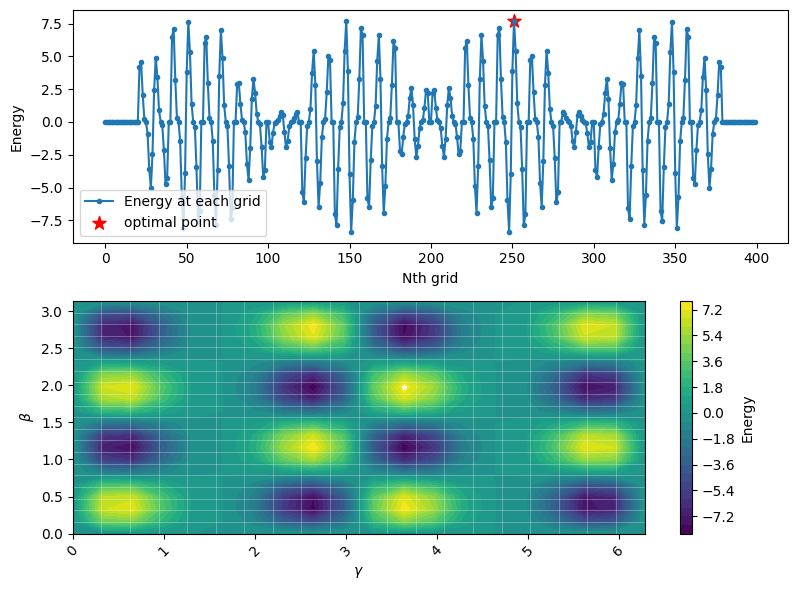

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.set_xlabel("Nth grid")
ax1.set_ylabel("Energy")
ax1.plot(result1["energy_history"], label="Energy at each grid", marker='.')
opt_x = int(np.argmax(result1["energy_history"]))
opt_y = result1["energy_history"][opt_x]
ax1.scatter(opt_x, opt_y, marker='*', s=100, label="optimal point", color="r")
ax1.legend()

ax2.set_xlim(0, 2*np.pi)
ax2.set_ylim(0, np.pi)
num_points = 20
x0, x1 = ax2.get_xlim()
y0, y1 = ax2.get_ylim()
x_edges = np.linspace(x0, x1, num_points + 1)
y_edges = np.linspace(y0, y1, num_points + 1)

#エネルギー図のプロット
trainer.plot(axis=ax2, fig=fig)

ax2.set_xticks(x_edges, minor=True)
ax2.set_yticks(y_edges, minor=True)
ax2.grid(which="minor", color="white", linestyle="-", linewidth=0.4, alpha=0.5)
ax2.tick_params(which="minor", bottom=False, left=False)
ax2.tick_params(axis='x', labelrotation=45)
fig.tight_layout()
plt.show()

**注意点**

`DepthOneScanTrainer`は、エネルギー計算を格子点ごとに行います。格子の数(`num_points`の二乗)が少ないと、コスト関数のランドスケープを十分正確に反映できません。つまり、得られる最大エネルギー値・最適パラメータ値が正確とはいえない可能性があります。`num_points`を増やせば、精度は増しますが実行時間がよりかかる欠点があります。

試しに`num_points`$=100$ にして、コスト関数のランドスケープや得られる値がどう変化するかみてみましょう。

In [19]:
trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator())
result_100 = trainer.train(cost_hamiltonian1, num_points=100)

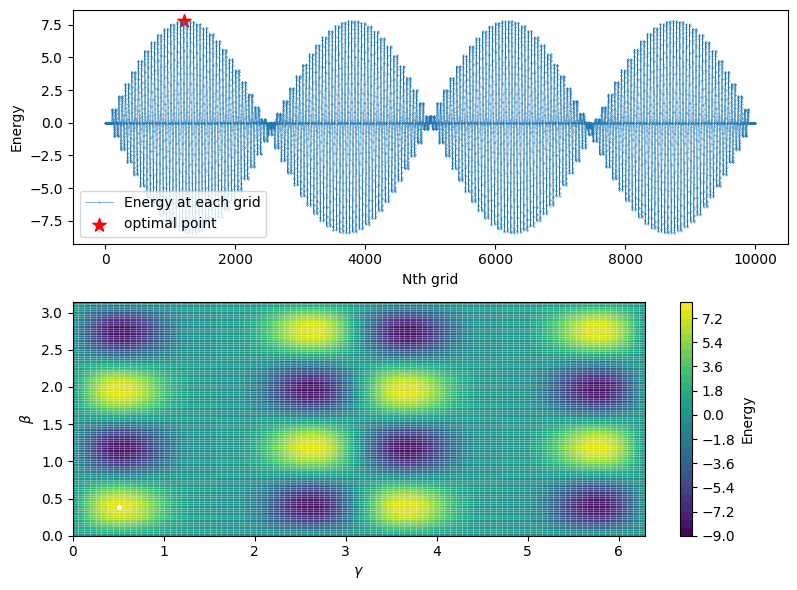

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.set_xlabel("Nth grid")
ax1.set_ylabel("Energy")
ax1.plot(result_100["energy_history"], label="Energy at each grid", marker='.', linewidth=0.4, markersize=0.5)
opt_x = int(np.argmax(result_100["energy_history"]))
opt_y = result_100["energy_history"][opt_x]
ax1.scatter(opt_x, opt_y, marker='*', s=100, label="optimal point", color="r")
ax1.legend()

ax2.set_xlim(0, 2*np.pi)
ax2.set_ylim(0, np.pi)
num_points = 100
x0, x1 = ax2.get_xlim()
y0, y1 = ax2.get_ylim()
x_edges = np.linspace(x0, x1, num_points + 1)
y_edges = np.linspace(y0, y1, num_points + 1)
trainer.plot(axis=ax2, fig=fig)
ax2.set_xticks(x_edges, minor=True)
ax2.set_yticks(y_edges, minor=True)
ax2.grid(which="minor", color="white", linestyle="-", linewidth=0.4, alpha=0.5)
ax2.tick_params(which="minor", bottom=False, left=False)
ax2.tick_params(axis='x')
fig.tight_layout()
plt.show()

In [21]:
print(f"最適化されたβ: {result_100["optimized_params"][0]}")
print(f"最適化されたγ: {result_100["optimized_params"][1]}")
print(f"エネルギー最大値: {result_100["energy"]}")

最適化されたβ: 0.3807991095260356
最適化されたγ: 0.5077321460347141
エネルギー最大値: 7.8061980992277595


### 例2. イジングコスト関数の最小化問題

\begin{align}
H_C^{\text{ising}}= -  \sum_{(i,j)\in E}J_{i,j} \,Z_iZ_j
\end{align}

例として、ランダムの25ノードのイジングコスト演算子を用意します。

In [22]:
with open("25node_example_ising.txt") as input_file:
    paulis = []
    for line in input_file.readlines():
        pauli, coeff = line.split(", ")
        paulis.append((pauli, float(coeff.replace("\n", ""))))
    cost_hamiltonian2 = SparsePauliOp.from_list(paulis)

print(cost_hamiltonian2)

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIZIIIZ', 'IIIIIIIIIIIIIIIIZIIIIIIZI', 'IIIIIIIIIIIIIIIIIIIIIZZII', 'IIIIIIIIIIIIIIIIIIIIZZIII', 'IIIIIIIIIIIIIIIIIIIZZIIII', 'IIIIIIIIIIIIIIIIIIZZIIIII', 'IIIIIIIIIIIIIIIIIZZIIIIII', 'IIIIIIIIIIIIIIIIZZIIIIIII', 'IIIIIIIIIIIIIIIZZIIIIIIII', 'IIIIIIIIIIIIIIZZIIIIIIIII', 'IIIIIIIIIIIIIZIIIIIIIIZII', 'IIIIIIIIZIIIIZIIIIIIIIIII', 'IIIIIIIIIIIIZIIIIIZIIIIII', 'IIIIIIIIIIIZIIZIIIIIIIIII', 'ZIIIIIIIIIIZIIIIIIIIIIIII', 'IIIIIIIIIZZIIIIIIIIIIIIII', 'IIIIIIIIZZIIIIIIIIIIIIIII', 'IIIIIIIZZIIIIIIIIIIIIIIII', 'IIIIIIZZIIIIIIIIIIIIIIIII', 'IIIIIZZIIIIIIIIIIIIIIIIII', 'IIIIZZIIIIIIIIIIIIIIIIIII', 'IIIIZIIIIIIIZIIIIIIIIIIII', 'IIIZZIIIIIIIIIIIIIIIIIIII', 'IIZZIIIIIIIIIIIIIIIIIIIII', 'IZZIIIIIIIIIIIIIIIIIIIIII', 'ZZIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[-1.+0.j, -1.+0.j, -1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j, -1.+0.j,  1.+0.j,
 -1.+0.j, -1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j,
 -1.+0.j,  1.+0.j,  1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j, -1.+0.j,

今回は最小値を`qaoa-training-pipeline`を使って求めてみます。このパッケージは最大値を求めるので、コスト関数の符号を反転させる必要があります

In [23]:
cost_op2 = - cost_hamiltonian2
trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator())
result2 = trainer.train(cost_op2, num_points=20)

In [24]:
print(f"最適化されたパラメータ: {result2["optimized_params"]}")
print(f"エネルギー最大値: {result2["energy"]}")

最適化されたパラメータ: [1.1574288723751869, 5.9524913436438185]
エネルギー最大値: 11.988856791489733


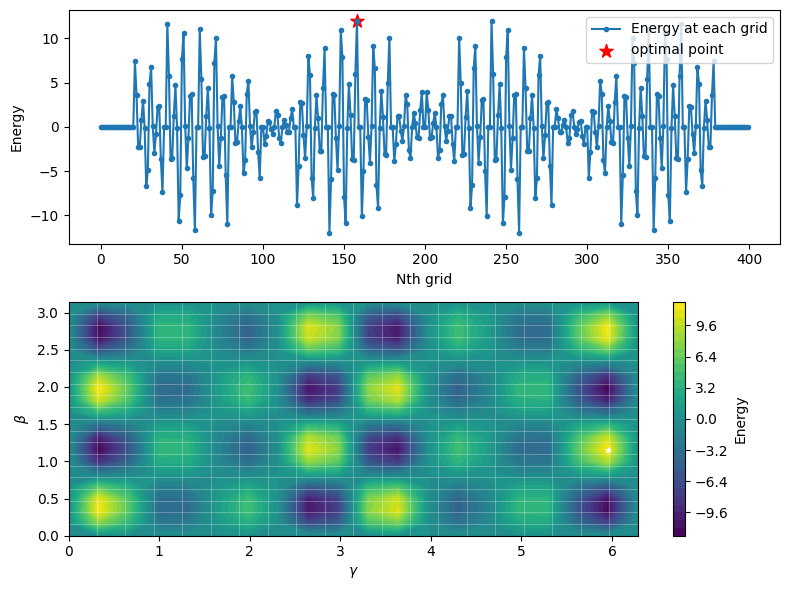

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.set_xlabel("Nth grid")
ax1.set_ylabel("Energy")
ax1.plot(result2["energy_history"], label="Energy at each grid", marker='.')
opt_x = int(np.argmax(result2["energy_history"]))
opt_y = result2["energy_history"][opt_x]
ax1.scatter(opt_x, opt_y, marker='*', s=100, label="optimal point", color="r")
ax1.legend()

ax2.set_xlim(0, 2*np.pi)
ax2.set_ylim(0, np.pi)
num_points = 20
x0, x1 = ax2.get_xlim()
y0, y1 = ax2.get_ylim()
x_edges = np.linspace(x0, x1, num_points + 1)
y_edges = np.linspace(y0, y1, num_points + 1)
trainer.plot(axis=ax2, fig=fig)
ax2.set_xticks(x_edges, minor=True)
ax2.set_yticks(y_edges, minor=True)
ax2.grid(which="minor", color="white", linestyle="-", linewidth=0.4, alpha=0.5)
ax2.tick_params(which="minor", bottom=False, left=False)
ax2.tick_params(axis='x')
fig.tight_layout()
plt.show()

ここからは、`qaoa-training-pipeline`で得られたパラメータを初期値として、さらに最適化を進めることをします。今回はシミュレーションで実行します

In [27]:
service = QiskitRuntimeService()
backend = service.backend("ibm_marrakesh")
sim = AerSimulator(method="matrix_product_state")
print(backend)

<IBMBackend('ibm_marrakesh')>


コストハミルトニアンを用いて`QAOAansatz`を構築します

In [74]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian2, reps=1)
circuit.measure_all()

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
candidate_circuit = pm.run(circuit)

In [47]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator, cost_history:list):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    cost_history.append(cost)

    return cost

In [48]:
cost_history = []
# Global variable
def Execute_QAOA(backend, cost_hamiltonian, cost_history):
    with Session(backend=backend) as session:
        # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
        estimator = Estimator(mode=session)
        estimator.options.default_shots = 1000

        result = minimize(
            cost_func_estimator,
            x0=result2["optimized_params"],
            args=(candidate_circuit, cost_hamiltonian, estimator, cost_history),
            method="COBYLA",
            tol=1e-2,
        )
        print(result)
        return result

In [49]:
noisless_result = Execute_QAOA(backend=sim, cost_hamiltonian=cost_hamiltonian2, cost_history=cost_history)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -12.335664335664331
       x: [ 1.934e+00  5.881e+00]
    nfev: 18
   maxcv: 0.0


In [76]:
print(f"Scipyによる最適されたパラメータ: {noisless_result.x}")
print(f"Scipによって得られたエネルギーy: {noisless_result.fun}")

Scipyによる最適されたパラメータ: [1.93359586 5.88109422]
Scipによって得られたエネルギーy: -12.335664335664331


| | training-pipeline | re-optimisation with Scipy |
|-----|-----|-----|
|Energy| 11.988856791489733|-12.335664335664331|
|Parameter|[1.1574288723751869, 5.9524913436438185]|[1.93359586, 5.88109422]|

再び最適化した結果、さらに深いエネルギーを求めることができました。`qaoa-training-pipeline`は必ずしも正確なエネルギー値を出すとは限りません。しかし`qaoa-training-pipeline`である程度最適化されたパラメータを初期値として、再び最適化を行うと、初期値をランダムに設定して最適化するよりいい値が出る可能性が高まります。

最後に再最適化によって得られた、パラメータを変分回路に代入して、サンプリングを実行してみましょう。

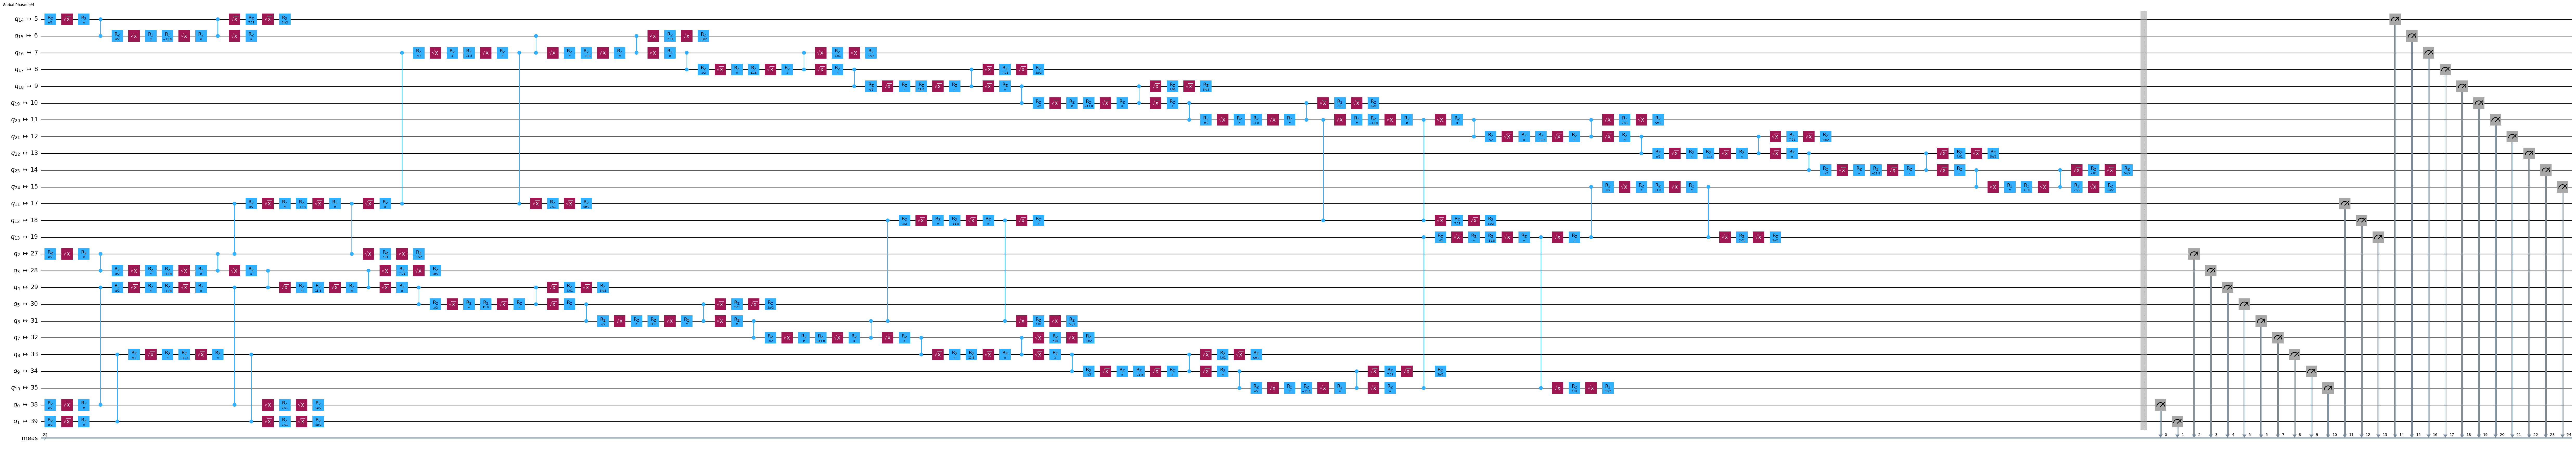

In [77]:
optimised_circuit = candidate_circuit.assign_parameters(noisless_result.x)
optimised_circuit.draw("mpl", fold=False, idle_wires=False)

In [37]:
# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=sim)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options

pub = (optimised_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}

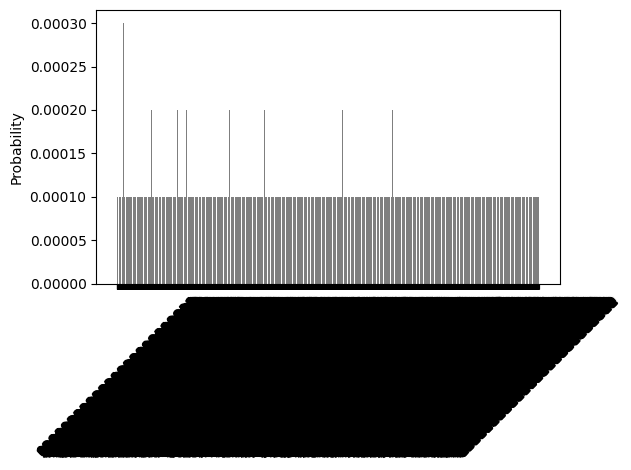

In [36]:
plt.figure(figsize=(30, 12))
plt.bar(list(final_distribution_bin.keys()), list(final_distribution_bin.values()), color="tab:grey")
plt.ylabel("Probability")
plt.xticks(rotation=90, fontsize=1)
plt.tight_layout()
plt.show()